In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from preprocessing import get_features_and_target
from visualizer import plot_visualizer, plot_visualizer_classification
import plotly.graph_objects as go
from sklearn.model_selection import StratifiedKFold
from preprocessing import get_features_and_target_classification
from tabpfn import TabPFNClassifier, TabPFNRegressor
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [3]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/development_data.csv")
#sc = StandardScaler()

target_column_class = "Category" 

x_train, y_train = get_features_and_target(train_df, target_column_class)
x_dev, y_dev = get_features_and_target(dev_df, target_column_class)

#x_train = sc.fit_transform(X=x_train)
#x_dev = sc.transform(x_dev)


# Defining Model

In [4]:
#model = 'XGBoost'
model = 'TabPFNClassifier'

# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [5]:
def compute_interfacial_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     f_pull = 1 * (np.pi/4) * (4 * np.sqrt(t))**2 * (0.7 * 365)
     return np.round(f_pull, 1) 

def compute_pullout_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     x = df[['Thickness A (mm)', 'Thickness B (mm)']].sum(axis=1)
     # x can be approximated to metal sheet thickness. Change 2*t either to t to use the thinner 
     # metal sheet or 2*x to test if the sum of both metal sheets give beter results
     f_pull = np.pi * ((4 * np.sqrt(t)) + 2*t)*t*365 
     return np.round(f_pull, 1) 

In [6]:
dev_df["Sample ID"].value_counts().sort_values().head()


Sample ID
6     1
8     1
14    1
16    1
22    1
Name: count, dtype: int64

In [7]:
x_dev

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,95,1500,0,124.19,1045.90,0.918,0.925
1,35,200,0,6.58,1171.55,0.931,0.922
2,95,1500,0,124.16,1078.29,0.925,0.930
3,35,200,0,6.61,916.16,0.936,0.927
4,35,1500,15,54.11,1440.24,0.930,0.946
...,...,...,...,...,...,...,...
94,60,1200,0,97.26,3624.99,0.624,0.627
95,60,1200,0,97.29,4311.15,0.623,0.630
96,60,1200,0,98.26,3490.11,0.627,0.626
97,60,1200,0,98.15,3311.58,0.619,0.624


# Fit Model

In [8]:
# Target value

classifier = TabPFNClassifier() 

classifier.fit(x_train,y_train)

predictions = classifier.predict(x_dev)

In [9]:
print(len(predictions   ), len(x_dev))

99 99


In [10]:
x_dev.tail()

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
94,60,1200,0,97.26,3624.99,0.624,0.627
95,60,1200,0,97.29,4311.15,0.623,0.630
96,60,1200,0,98.26,3490.11,0.627,0.626
97,60,1200,0,98.15,3311.58,0.619,0.624
98,60,1200,0,98.09,2944.84,0.625,0.624


# Add Pullforce as Target

In [11]:
pullforces = []

for i in range(len(predictions)):
    row_x_df = x_dev.iloc[i:i+1]

    if predictions[i] == "Bad":
        value = compute_interfacial_failure(row_x_df).iloc[0]
    else:
        value = compute_pullout_failure(row_x_df).iloc[0]
    pullforces.append(value)

pullforces = np.array(pullforces)


In [12]:
print(predictions)

['Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good']


In [13]:
print(x_train)

     Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  Current (A)  \
0                35                200            0       6.82      1081.47   
1                35               1500            0      52.25      2014.73   
2                95                200            0      16.57      1321.93   
3                95                200            0      41.42      1615.83   
4                35               1500            0      63.82      1137.29   
..              ...                ...          ...        ...          ...   
290              60               1200            0      98.51      4429.61   
291              60               1200            0      97.32      2636.69   
292              60               1200            0      98.07      3601.67   
293              60               1200            0      97.09      4161.74   
294              60               1200            0      96.34      3436.97   

     Thickness A (mm)  Thickness B (mm)  
0        

In [14]:
pullforces

array([5967. , 2960.3, 6042.8, 2976.3, 6097.2, 2976.3, 6097.2, 3018.1,
       3423.9, 3170.5, 3245.7, 3237.3, 3254.1, 3304.7, 3195.5, 3245.7,
       3153.9, 3203.8, 3087.8, 3330.1, 3245.7, 3270.9, 3162.2, 3187.1,
       3220.5, 3220.5, 3145.6, 3187.1, 3129. , 3162.2, 3096. , 3112.5,
       3220.5, 3228.9, 3096. , 3254.1, 3270.9, 3137.3, 3170.5, 3212.2,
       3137.3, 3254.1, 3228.9, 3145.6, 3212.2, 3220.5, 3254.1, 3262.5,
       3145.6, 3071.3, 3055. , 3038.6, 3178.8, 3129. , 3162.2, 3145.6,
       3170.5, 3120.8, 3162.2, 3178.8, 3153.9, 3104.3, 3137.3, 3153.9,
       3129. , 3137.3, 3096. , 3055. , 3079.6, 3137.3, 3104.3, 3220.5,
       3162.2, 3178.8, 3112.5, 3104.3, 3137.3, 3104.3, 3129. , 3187.1,
       3212.2, 3145.6, 3195.5, 3170.5, 3170.5, 3112.5, 3120.8, 3162.2,
       3153.9, 3170.5, 3038.6, 3112.5, 3153.9, 3071.3, 3153.9, 3145.6,
       3170.5, 3112.5, 3153.9])

# Check Validation Data

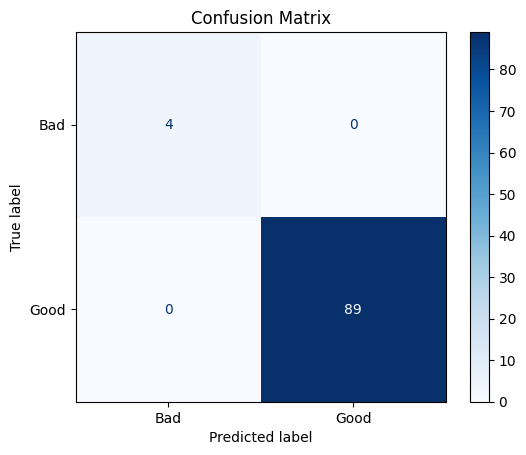

F1 Score: 0.6557971014492754


In [15]:
# Plot classification
plot_visualizer_classification(
    y_true=y_dev,
    y_pred=predictions,
    class_labels=["Bad", "Good"],
    title=f"Confusion Matrix"
)

In [16]:
# Category array (must be aligned with y_dev)
categories = dev_df.groupby("Sample ID")["Category"].first().values
y_dev_regression = dev_df.groupby("Sample ID")['PullTest (N)'].first()

plot_visualizer(
    true_vals=y_dev_regression,
    pred_vals=pullforces,
    categories=categories,
    title=f"Validation Samples: True vs Prediction (TabPFN) by Category"
)

In [17]:
x_dev.head(10)

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,95,1500,0,124.19,1045.90,0.918,0.925
1,35,200,0,6.58,1171.55,0.931,0.922
2,95,1500,0,124.16,1078.29,0.925,0.930
3,35,200,0,6.61,916.16,0.936,0.927
4,35,1500,15,54.11,1440.24,0.930,0.946
5,35,200,15,27.19,1191.93,0.933,0.927
6,35,1500,15,55.03,1168.61,0.939,0.930
7,95,200,15,33.27,1025.97,0.940,0.945
8,60,1000,0,77.33,3211.91,0.656,0.656
9,60,1000,0,77.04,2992.93,0.637,0.626


0        Good
1         Bad
2        Good
3         Bad
4     Explode
       ...   
94       Good
95       Good
96       Good
97       Good
98    Explode
Name: Category, Length: 99, dtype: object

array(['Good', 'Bad', 'Good', 'Bad', 'Good', 'Bad', 'Good', 'Bad', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good'], dtype=object)

In [19]:
pullforces

array([5967. , 2960.3, 6042.8, 2976.3, 6097.2, 2976.3, 6097.2, 3018.1,
       3423.9, 3170.5, 3245.7, 3237.3, 3254.1, 3304.7, 3195.5, 3245.7,
       3153.9, 3203.8, 3087.8, 3330.1, 3245.7, 3270.9, 3162.2, 3187.1,
       3220.5, 3220.5, 3145.6, 3187.1, 3129. , 3162.2, 3096. , 3112.5,
       3220.5, 3228.9, 3096. , 3254.1, 3270.9, 3137.3, 3170.5, 3212.2,
       3137.3, 3254.1, 3228.9, 3145.6, 3212.2, 3220.5, 3254.1, 3262.5,
       3145.6, 3071.3, 3055. , 3038.6, 3178.8, 3129. , 3162.2, 3145.6,
       3170.5, 3120.8, 3162.2, 3178.8, 3153.9, 3104.3, 3137.3, 3153.9,
       3129. , 3137.3, 3096. , 3055. , 3079.6, 3137.3, 3104.3, 3220.5,
       3162.2, 3178.8, 3112.5, 3104.3, 3137.3, 3104.3, 3129. , 3187.1,
       3212.2, 3145.6, 3195.5, 3170.5, 3170.5, 3112.5, 3120.8, 3162.2,
       3153.9, 3170.5, 3038.6, 3112.5, 3153.9, 3071.3, 3153.9, 3145.6,
       3170.5, 3112.5, 3153.9])

# Check Validation Loss and R2

In [20]:
# Calculate MAE and RMSE and R2
mae  = mean_absolute_error(y_dev_regression, pullforces)
rmse = np.sqrt(mean_squared_error(y_dev_regression, pullforces))
R2   = r2_score(y_dev_regression, pullforces)


print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {R2:.2f}")

MAE:  332.56
RMSE: 501.80
R2: -0.98


# Cross Validation

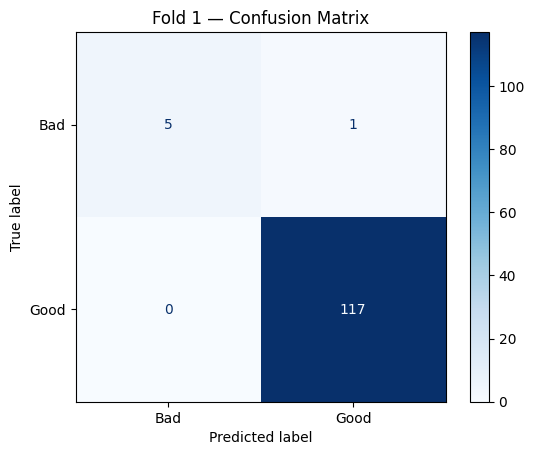

F1 Score: 0.622702434177844



=== Fold 1 ===
Pullout:
 MAE=463.58,
 RMSE=893.71,
 R²=-4.51

Interfacial:
 MAE=916.50,
 RMSE=948.20,
 R²=-5.20

Hybrid:
 MAE=347.23,
 RMSE=517.61,
 R²=-0.85


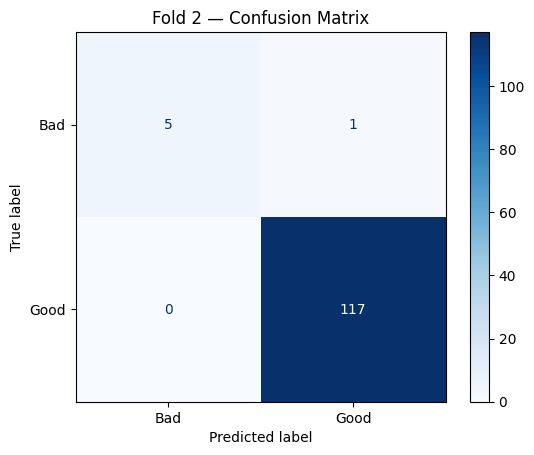

F1 Score: 0.6240179573512906



=== Fold 2 ===
Pullout:
 MAE=417.94,
 RMSE=816.26,
 R²=-2.05

Interfacial:
 MAE=937.65,
 RMSE=991.14,
 R²=-3.50

Hybrid:
 MAE=299.54,
 RMSE=393.76,
 R²=0.29


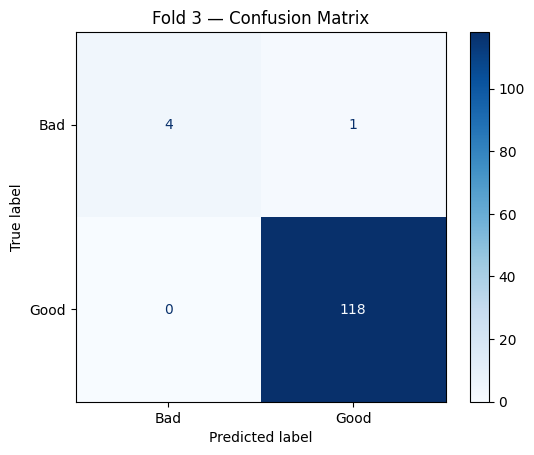

F1 Score: 0.6173847316704459



=== Fold 3 ===
Pullout:
 MAE=413.04,
 RMSE=779.21,
 R²=-3.14

Interfacial:
 MAE=917.96,
 RMSE=959.34,
 R²=-5.27

Hybrid:
 MAE=319.20,
 RMSE=441.89,
 R²=-0.33

=== FINAL CROSS‑VALIDATION RESULTS ===

--- Pullout Model ---
F1 mean: 0.62
MAE mean: 431.52
RMSE mean: 829.73
R² mean: -3.23

--- Interfacial Model ---
MAE mean: 924.04
RMSE mean: 966.22
R² mean: -4.66

--- Hybrid Model ---
MAE mean: 321.99
RMSE mean: 451.09
R² mean: -0.30


In [21]:
cross_df = pd.read_csv("data/train_dev_data.csv")
target_column_regression = "PullTest (N)" 

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

pu_calc_mae, pu_calc_rmse, pu_calc_r2 = [], [], [] 
if_calc_mae, if_calc_rmse, if_calc_r2 = [], [], [] 
hybrid_mae, hybrid_rmse, hybrid_r2 = [], [], [] 
f1_scores = []

for fold, (train_index, val_index) in enumerate(skf.split(cross_df["Sample ID"], cross_df["Category"])):
    # Build fold-specific data
    train_df = cross_df.iloc[train_index].copy()
    val_df   = cross_df.iloc[val_index].copy()

    # Group targets by Sample ID (SAME as non‑CV pipeline)
    y_train_reg = train_df.groupby("Sample ID")["PullTest (N)"].first()
    y_val_reg   = val_df.groupby("Sample ID")["PullTest (N)"].first()

    # Build feature matrices at Sample ID level
    x_train = train_df.groupby("Sample ID").first()
    x_val   = val_df.groupby("Sample ID").first()

    x_tr_class, y_tr_class = get_features_and_target(x_train, target_column_class)
    x_val_class, y_val_class = get_features_and_target(x_val, target_column_class)

    x_tr_reg, y_tr_reg = get_features_and_target(x_train, target_column_regression)
    x_val_reg, y_val_reg = get_features_and_target(x_val, target_column_regression)

    # Predict labels
    predictions = classifier.predict(x_val_class)
    f1 = f1_score(y_val_class, predictions, average="macro")
    f1_scores.append(f1)
    
    # Plot classification results for this fold
    plot_visualizer_classification(
        y_true=y_val_class,
        y_pred=predictions,
        class_labels=["Bad", "Good"],
        title=f"Fold {fold+1} — Confusion Matrix"
    )

    pullout_list = []
    interfacial_list = []
    pullforces = []

    for i in range(len(predictions)):
        row_x_df = x_val.iloc[i:i+1]   # FIX: use fold validation data

        if predictions[i] == "Bad":
            interfacial = compute_interfacial_failure(row_x_df).iloc[0]
            pullout = compute_pullout_failure(row_x_df).iloc[0]
            pullforces.append(interfacial)
        else:
            interfacial = compute_interfacial_failure(row_x_df).iloc[0]
            pullout = compute_pullout_failure(row_x_df).iloc[0]
            pullforces.append(pullout)


        # FIX: append inside loop
        interfacial_list.append(interfacial) 
        pullout_list.append(pullout) 

    pullforces = np.array(pullforces)

    pu_calc_mae.append(mean_absolute_error(y_val_reg, pullout_list)) 
    pu_calc_rmse.append(np.sqrt(mean_squared_error(y_val_reg, pullout_list))) 
    pu_calc_r2.append(r2_score(y_val_reg, pullout_list))  

    if_calc_mae.append(mean_absolute_error(y_val_reg, interfacial_list)) 
    if_calc_rmse.append(np.sqrt(mean_squared_error(y_val_reg, interfacial_list))) 
    if_calc_r2.append(r2_score(y_val_reg, interfacial_list))  

    hybrid_mae.append(mean_absolute_error(y_val_reg, pullforces)) 
    hybrid_rmse.append(np.sqrt(mean_squared_error(y_val_reg, pullforces))) 
    hybrid_r2.append(r2_score(y_val_reg, pullforces))  

    # Categories
    categories= cross_df.iloc[val_index]["Category"].values

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=pullout_list,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction (TabPFN) by Category with Pullout Failure"
    )

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=interfacial_list,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction (TabPFN) by Category with Interfacial Failure"
    )

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=pullforces,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction (TabPFN) by Category with Pullout-Interfacial Hybrid"
    )

    print(f"\n=== Fold {fold+1} ===") 
    print(f"Pullout:\n MAE={pu_calc_mae[-1]:.2f},\n RMSE={pu_calc_rmse[-1]:.2f},\n R²={pu_calc_r2[-1]:.2f}\n")
    print(f"Interfacial:\n MAE={if_calc_mae[-1]:.2f},\n RMSE={if_calc_rmse[-1]:.2f},\n R²={if_calc_r2[-1]:.2f}\n")
    print(f"Hybrid:\n MAE={hybrid_mae[-1]:.2f},\n RMSE={hybrid_rmse[-1]:.2f},\n R²={hybrid_r2[-1]:.2f}")

print("\n=== FINAL CROSS‑VALIDATION RESULTS ===") 
print("\n--- Pullout Model ---") 
print(f"F1 mean: {np.mean(f1_scores):.2f}") 
print(f"MAE mean: {np.mean(pu_calc_mae):.2f}") 
print(f"RMSE mean: {np.mean(pu_calc_rmse):.2f}") 
print(f"R² mean: {np.mean(pu_calc_r2):.2f}")

print("\n--- Interfacial Model ---") 
print(f"MAE mean: {np.mean(if_calc_mae):.2f}") 
print(f"RMSE mean: {np.mean(if_calc_rmse):.2f}") 
print(f"R² mean: {np.mean(if_calc_r2):.2f}")

print("\n--- Hybrid Model ---") 
print(f"MAE mean: {np.mean(hybrid_mae):.2f}") 
print(f"RMSE mean: {np.mean(hybrid_rmse):.2f}") 
print(f"R² mean: {np.mean(hybrid_r2):.2f}") 